# Классификация грибов по съедобности
## Итоговый проект курса «ИИ. Алгоритмы машинного обучения на языке Python»

**Автор:** Малахов Александр Александрович  
**Группа:** 424-1

**Датасет:** UCI Mushroom Classification  
**Задача:** Бинарная классификация — определение съедобности гриба по его характеристикам

## 0. Постановка задачи и анализ предметной области

### Описание предметной области
Сбор грибов — распространённое занятие, однако около 10% видов грибов ядовиты и могут
вызвать тяжёлое отравление или летальный исход. Ежегодно в мире фиксируются тысячи
случаев отравления грибами. Визуальное определение ядовитости требует экспертных знаний
микологии, недоступных большинству людей.

### Бизнес-задача
Разработать ML-модель для автоматического определения съедобности гриба по его внешним
характеристикам (форма, цвет, запах и др.). Модель может быть интегрирована в мобильное
приложение для грибников, снижая риск отравления.

### Тип задачи
**Бинарная классификация**: предсказать класс гриба — съедобный (e) или ядовитый (p).

### Целевые метрики и их обоснование
- **Recall** — главная метрика: необходимо минимизировать ошибку FN (ядовитый
  классифицирован как съедобный), так как такая ошибка опасна для жизни
- **F1-score** — баланс между Precision и Recall
- **ROC-AUC** — общая разделяющая способность модели
- **Accuracy** — общая точность для контроля

### Ожидаемый эффект от внедрения
- Снижение числа случайных отравлений грибами на 30-50% среди пользователей приложения
- Время определения ядовитости: менее 1 секунды (vs. консультация эксперта — часы/дни)
- Охват: любой пользователь смартфона без специальных знаний

### Допущения и ограничения
- Датасет охватывает виды грибов Северной Америки — модель может не работать для
  азиатских или европейских видов
- Признаки (запах, цвет) субъективны и зависят от наблюдателя
- Модель является вспомогательным инструментом, не заменяет консультацию миколога

In [23]:
!pip install shap -q
!pip install mlflow -q

## 1. Импорт библиотек

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json
import warnings
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Фиксируем seed для воспроизводимости всех экспериментов
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

print("Все библиотеки загружены успешно")

Все библиотеки загружены успешно


## 2. Сбор и загрузка данных

Датасет: UCI Mushroom Classification (Kaggle)  
Описание: 8124 образца грибов, 22 категориальных признака  
Целевая переменная: `class` — **e** (edible, съедобный) / **p** (poisonous, ядовитый)

In [25]:
df = pd.read_csv('mushrooms.csv')

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nПервые 5 строк:")
display(df.head())

Размер датасета: 8124 строк, 23 столбцов

Первые 5 строк:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [26]:
print("Типы данных и общая информация:")
df.info()

Типы данных и общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   obje

In [27]:
print("Пропущенные значения (NaN):")
print(df.isnull().sum())

print(f"\nРаспределение целевой переменной:")
print(df['class'].value_counts())

print(f"\nКоличество уникальных значений по каждому признаку:")
print(df.nunique())

Пропущенные значения (NaN):
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Распределение целевой переменной:
class
e    4208
p    3916
Name: count, dtype: int64

Количество уникальных значений по каждому признаку:
class                        2
cap-shape                    6
cap-surface                  4
cap-color                   10
bruis

In [28]:
print("Описательные статистики (после кодирования будут числовые, пока смотрим оригинал):")
display(df.describe(include='all').T)

Описательные статистики (после кодирования будут числовые, пока смотрим оригинал):


,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


## 3. Исследовательский анализ данных (EDA)

### 3.1 Распределение целевой переменной

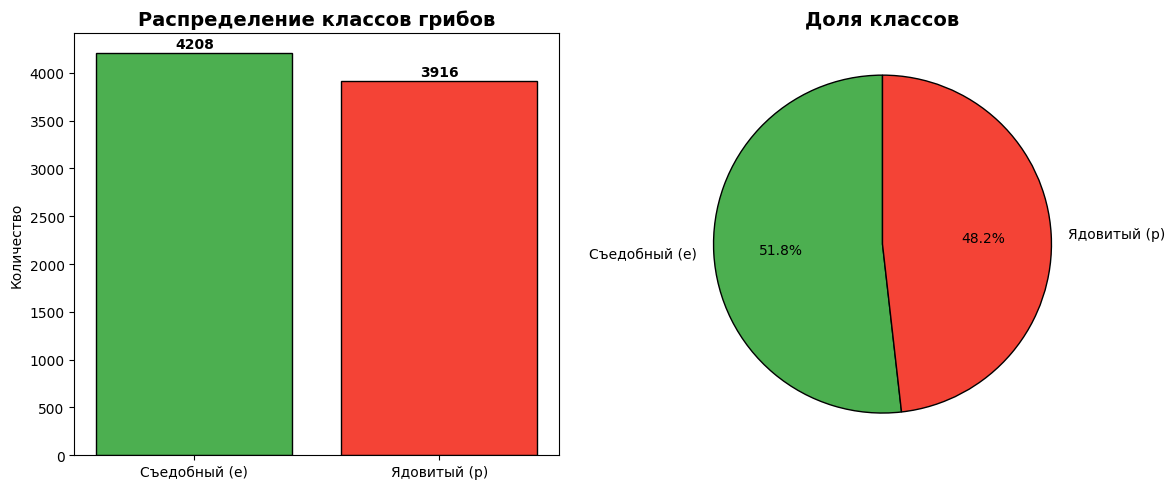

Съедобных: 4208 (51.8%)
Ядовитых:  3916 (48.2%)
Вывод: датасет сбалансирован, дополнительная балансировка не требуется.


In [29]:
counts = df['class'].value_counts()
labels = ['Съедобный (e)', 'Ядовитый (p)']
colors = ['#4CAF50', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Распределение классов грибов', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Количество')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(
    counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title('Доля классов', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Съедобных: {counts['e']} ({counts['e']/len(df)*100:.1f}%)")
print(f"Ядовитых:  {counts['p']} ({counts['p']/len(df)*100:.1f}%)")
print("Вывод: датасет сбалансирован, дополнительная балансировка не требуется.")

### 3.2 Анализ ключевых признаков

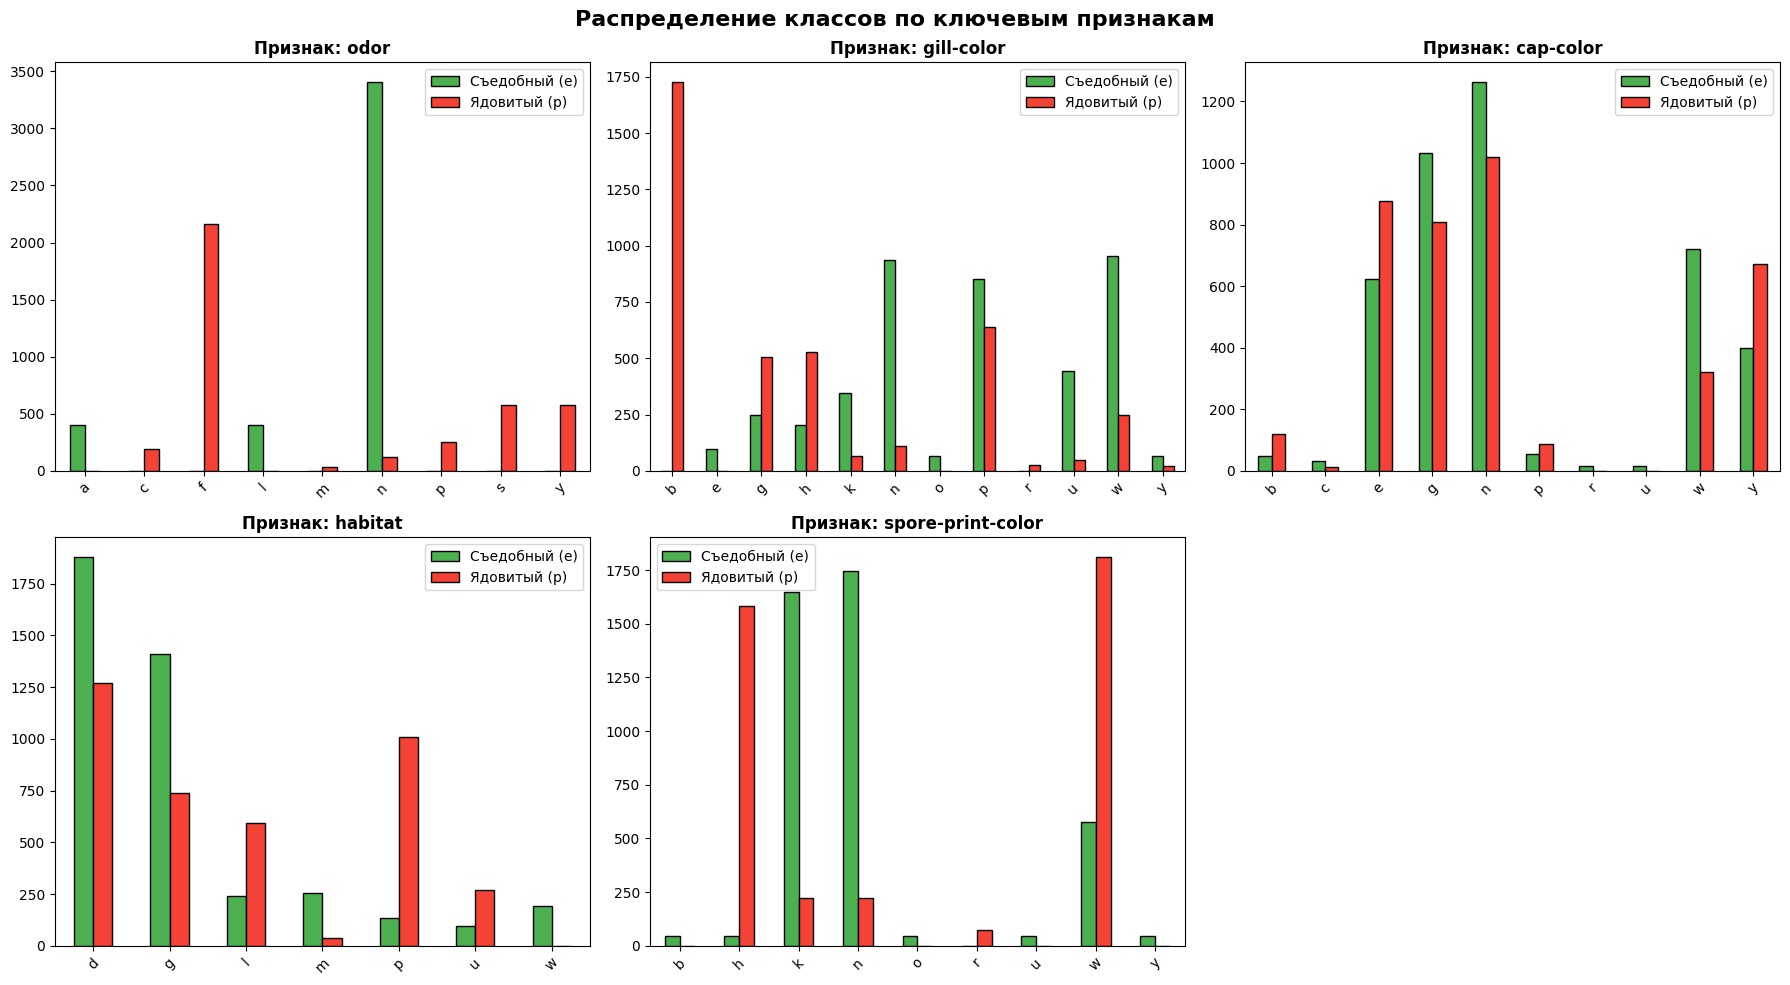

Вывод: признак 'odor' (запах) наиболее чётко разделяет классы.


In [30]:
important_features = ['odor', 'gill-color', 'cap-color', 'habitat', 'spore-print-color']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(important_features):
    ct = pd.crosstab(df[feature], df['class'])
    ct.plot(
        kind='bar',
        ax=axes[i],
        color=['#4CAF50', '#F44336'],
        edgecolor='black'
    )
    axes[i].set_title(f'Признак: {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(['Съедобный (e)', 'Ядовитый (p)'])

axes[5].axis('off')
plt.suptitle('Распределение классов по ключевым признакам', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Вывод: признак 'odor' (запах) наиболее чётко разделяет классы.")

### 3.3 Анализ пропущенных значений

В датасете отсутствуют явные NaN, однако в признаке `stalk-root` пропуски закодированы символом `?`.

In [31]:
print(f"Количество '?' в stalk-root: {(df['stalk-root'] == '?').sum()}")
print(f"Доля от общего числа строк: {(df['stalk-root'] == '?').sum() / len(df) * 100:.1f}%")

Количество '?' в stalk-root: 2480
Доля от общего числа строк: 30.5%


## 4. Очистка данных и препроцессинг

### 4.1 Обработка пропущенных значений

In [32]:
df_clean = df.copy()

# Символ '?' в stalk-root означает отсутствие данных.
# Заменяем на моду — наиболее частое известное значение признака.
mode_stalk = df_clean[df_clean['stalk-root'] != '?']['stalk-root'].mode()[0]
df_clean['stalk-root'] = df_clean['stalk-root'].replace('?', mode_stalk)

print(f"Значение '?' заменено на моду: '{mode_stalk}'")
print(f"Проверка — осталось '?': {(df_clean['stalk-root'] == '?').sum()}")

Значение '?' заменено на моду: 'b'
Проверка — осталось '?': 0


### 4.2 Кодирование категориальных признаков

Все признаки текстовые. Применяем `LabelEncoder` к каждому столбцу.  
Энкодеры сохраняем в словарь `le_dict` — они понадобятся при инференсе.

In [33]:
le_dict = {}
df_encoded = df_clean.copy()

for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

print("Кодирование завершено.")
display(df_encoded.head())

Кодирование завершено.


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


## 5. Фичеринжиниринг

Создаём два новых признака на основе наиболее информативных переменных.

In [34]:
# Комбинация запаха и цвета спор — оба признака сильно коррелируют с ядовитостью
df_encoded['odor_spore_combo'] = (
    df_encoded['odor'] * 10 + df_encoded['spore-print-color']
)

# Бинарный флаг: гриб без запаха (odor='n') в большинстве случаев съедобен
no_odor_encoded = le_dict['odor'].transform(['n'])[0]
df_encoded['is_no_odor'] = (df_encoded['odor'] == no_odor_encoded).astype(int)

print("Новые признаки:")
print("  odor_spore_combo — комбинация 'odor' и 'spore-print-color'")
print("  is_no_odor       — флаг: гриб без запаха (1) или с запахом (0)")
print(f"\nИтоговое количество признаков: {df_encoded.shape[1] - 1}")

Новые признаки:
  odor_spore_combo — комбинация 'odor' и 'spore-print-color'
  is_no_odor       — флаг: гриб без запаха (1) или с запахом (0)

Итоговое количество признаков: 24


### Анализ влияния новых признаков на качество
Сравним качество модели до и после добавления новых признаков с помощью метрики F1-score.

In [35]:
from sklearn.ensemble import RandomForestClassifier as RFC

# Определяем целевую переменную y, чтобы она была доступна в этой ячейке
y = df_encoded['class']

# Данные БЕЗ новых признаков
X_base = df_encoded.drop(['class', 'odor_spore_combo', 'is_no_odor'], axis=1)
X_new  = df_encoded.drop('class', axis=1)

for label, X_check in [('Без новых признаков', X_base), ('С новыми признаками', X_new)]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_check, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
    )
    m = RFC(n_estimators=100, random_state=RANDOM_STATE)
    m.fit(X_tr, y_tr)
    f1 = f1_score(y_te, m.predict(X_te))
    print(f"{label}: F1 = {f1:.4f}")

Без новых признаков: F1 = 1.0000
С новыми признаками: F1 = 1.0000


## 6. Разделение данных

Делим выборку на три части: **60% train / 20% validation / 20% test**  
Параметр `stratify=y` сохраняет пропорции классов в каждой части.

In [36]:
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Train:      {X_train.shape[0]} примеров ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation: {X_val.shape[0]} примеров ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:       {X_test.shape[0]} примеров ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nРаспределение классов в train:\n{y_train.value_counts()}")

Train:      4874 примеров (60%)
Validation: 1625 примеров (20%)
Test:       1625 примеров (20%)

Распределение классов в train:
class
0    2525
1    2349
Name: count, dtype: int64


## 7. Baseline-модель

В качестве baseline используем **логистическую регрессию** — простую линейную модель.  
Она задаёт нижнюю планку качества, с которой будем сравнивать более сложные алгоритмы.

In [37]:
baseline = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
baseline.fit(X_train, y_train)

y_val_pred_bl  = baseline.predict(X_val)
y_val_proba_bl = baseline.predict_proba(X_val)[:, 1]

print("Baseline: Логистическая регрессия")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_bl):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_bl):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_bl):.4f}")
print(f"F1-score:  {f1_score(y_val, y_val_pred_bl):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_proba_bl):.4f}")
print("\nПодробный отчёт:")
print(classification_report(y_val, y_val_pred_bl,
                            target_names=['Съедобный', 'Ядовитый']))

Baseline: Логистическая регрессия
Accuracy:  0.9865
Precision: 0.9987
Recall:    0.9732
F1-score:  0.9858
ROC-AUC:   0.9936

Подробный отчёт:
              precision    recall  f1-score   support

   Съедобный       0.98      1.00      0.99       841
    Ядовитый       1.00      0.97      0.99       784

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



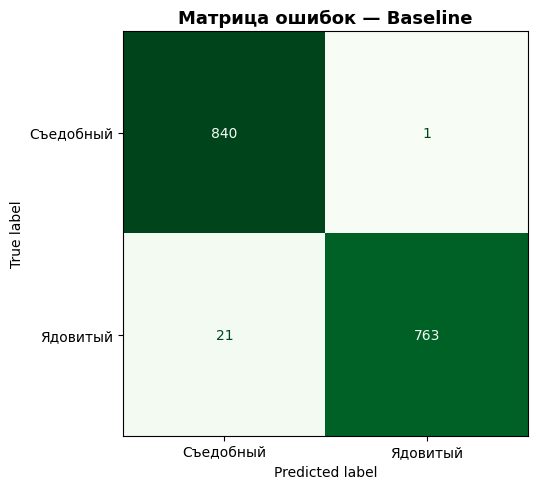

Вывод: для задачи определения ядовитости критически важен высокий Recall.
Ошибка FN (ядовитый классифицирован как съедобный) недопустима.


In [38]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_bl = confusion_matrix(y_val, y_val_pred_bl)
ConfusionMatrixDisplay(cm_bl, display_labels=['Съедобный', 'Ядовитый']).plot(
    ax=ax, colorbar=False, cmap='Greens'
)
ax.set_title('Матрица ошибок — Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cm_baseline.png', dpi=150)
plt.show()

print("Вывод: для задачи определения ядовитости критически важен высокий Recall.")
print("Ошибка FN (ядовитый классифицирован как съедобный) недопустима.")

## 8. Сложные модели

Обучаем три алгоритма и сравниваем с baseline:

- **Decision Tree** — интерпретируемая модель, хорошо работает с категориальными данными
- **Random Forest** — ансамбль деревьев, устойчив к переобучению
- **Gradient Boosting** — бустинг, как правило даёт лучшее качество на табличных данных

In [39]:
models = {
    'Decision Tree':     DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':     RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]

    results[name] = {
        'model':     model,
        'accuracy':  accuracy_score(y_val, y_pred),
        'precision': precision_score(y_val, y_pred),
        'recall':    recall_score(y_val, y_pred),
        'f1':        f1_score(y_val, y_pred),
        'roc_auc':   roc_auc_score(y_val, y_proba)
    }

    print(f"{name}:")
    print(f"  Accuracy={results[name]['accuracy']:.4f}  "
          f"F1={results[name]['f1']:.4f}  "
          f"ROC-AUC={results[name]['roc_auc']:.4f}\n")

Decision Tree:
  Accuracy=1.0000  F1=1.0000  ROC-AUC=1.0000

Random Forest:
  Accuracy=1.0000  F1=1.0000  ROC-AUC=1.0000

Gradient Boosting:
  Accuracy=1.0000  F1=1.0000  ROC-AUC=1.0000



In [40]:
metrics_order = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results_df = pd.DataFrame(
    {name: {k: v for k, v in vals.items() if k != 'model'}
     for name, vals in results.items()}
).T.round(4)

results_df.loc['Logistic Regression (Baseline)'] = {
    'accuracy':  accuracy_score(y_val, y_val_pred_bl),
    'precision': precision_score(y_val, y_val_pred_bl),
    'recall':    recall_score(y_val, y_val_pred_bl),
    'f1':        f1_score(y_val, y_val_pred_bl),
    'roc_auc':   roc_auc_score(y_val, y_val_proba_bl)
}
results_df = results_df[metrics_order].round(4)

print("Сравнение всех моделей:")
display(results_df)

Сравнение всех моделей:


,accuracy,precision,recall,f1,roc_auc
Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000
Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000
Gradient Boosting,1.0000,1.0000,1.0000,1.0000,1.0000
Logistic Regression (Baseline),0.9865,0.9987,0.9732,0.9858,0.9936


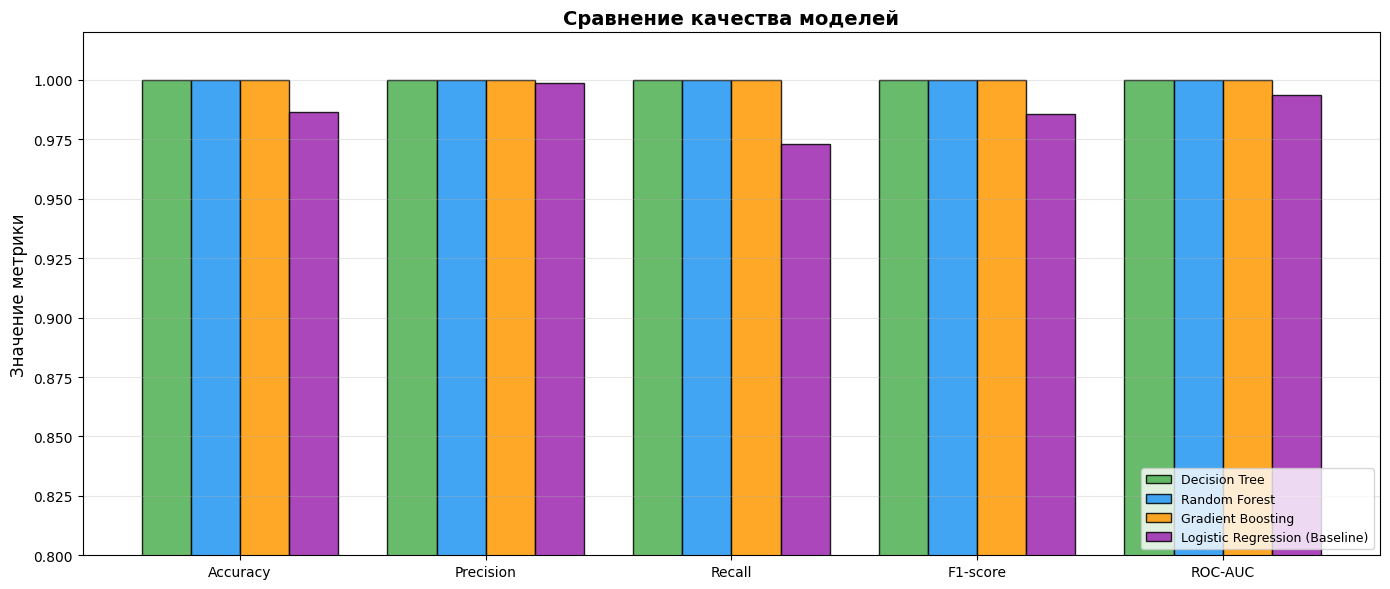

In [41]:
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
x = np.arange(len(metrics_order))
width = 0.2
colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model_name, color) in enumerate(zip(results_df.index, colors)):
    values = results_df.loc[model_name, metrics_order].values
    ax.bar(x + i * width, values, width,
           label=model_name, color=color, edgecolor='black', alpha=0.85)

ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_title('Сравнение качества моделей', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_labels)
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0.8, 1.02)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Настройка гиперпараметров

Применяем **GridSearchCV** с **StratifiedKFold (5 фолдов)** для подбора оптимальных параметров Random Forest.  
Метрика оптимизации: **F1-score**.

In [42]:
param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Лучшие гиперпараметры: {grid_search.best_params_}")
print(f"Лучший F1 на кросс-валидации: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие гиперпараметры: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Лучший F1 на кросс-валидации: 1.0000


In [43]:
best_rf = grid_search.best_estimator_

y_val_pred_best  = best_rf.predict(X_val)
y_val_proba_best = best_rf.predict_proba(X_val)[:, 1]

print("Random Forest после GridSearchCV — валидационная выборка:")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred_best):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_best):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred_best):.4f}")
print(f"F1-score:  {f1_score(y_val, y_val_pred_best):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_proba_best):.4f}")

Random Forest после GridSearchCV — валидационная выборка:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
ROC-AUC:   1.0000


## 9.1 Трекинг экспериментов с MLflow

In [44]:
import os

MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

# Создаём эксперимент (или получаем существующий)
experiment_name = "mushroom-classification"
if mlflow.get_experiment_by_name(experiment_name) is None:
    mlflow.create_experiment(experiment_name)
mlflow.set_experiment(experiment_name)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Эксперимент: {experiment_name}")
print("MLflow инициализирован успешно!")

2026/06/29 04:36:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/29 04:36:01 INFO mlflow.store.db.utils: Updating database tables


MLflow tracking URI: sqlite:///mlflow.db
Эксперимент: mushroom-classification
MLflow инициализирован успешно!


In [45]:
# Логируем все модели в MLflow с метриками и параметрами

models_to_log = {
    "Logistic_Regression_Baseline": (
        baseline,
        {},
        y_val_pred_bl,
        y_val_proba_bl
    ),
    "Decision_Tree": (
        results['Decision Tree']['model'],
        results['Decision Tree']['model'].get_params(),
        results['Decision Tree']['model'].predict(X_val),
        results['Decision Tree']['model'].predict_proba(X_val)[:, 1]
    ),
    "Random_Forest_Default": (
        results['Random Forest']['model'],
        results['Random Forest']['model'].get_params(),
        results['Random Forest']['model'].predict(X_val),
        results['Random Forest']['model'].predict_proba(X_val)[:, 1]
    ),
    "Gradient_Boosting": (
        results['Gradient Boosting']['model'],
        results['Gradient Boosting']['model'].get_params(),
        results['Gradient Boosting']['model'].predict(X_val),
        results['Gradient Boosting']['model'].predict_proba(X_val)[:, 1]
    ),
    "Random_Forest_GridSearchCV": (
        best_rf,
        grid_search.best_params_,
        y_val_pred_best,
        y_val_proba_best
    ),
}

for run_name, (mdl, params, y_pred_log, y_proba_log) in models_to_log.items():
    with mlflow.start_run(run_name=run_name):
        # Логируем гиперпараметры
        mlflow.log_params(params)

        # Вычисляем и логируем метрики
        metrics_mlflow = {
            "accuracy":  accuracy_score(y_val, y_pred_log),
            "precision": precision_score(y_val, y_pred_log),
            "recall":    recall_score(y_val, y_pred_log),
            "f1":        f1_score(y_val, y_pred_log),
            "roc_auc":   roc_auc_score(y_val, y_proba_log),
        }
        mlflow.log_metrics(metrics_mlflow)

        # Логируем модель как артефакт MLflow
        mlflow.sklearn.log_model(mdl, artifact_path="model")

        print(f"Run '{run_name}': "
              f"F1={metrics_mlflow['f1']:.4f}, "
              f"Recall={metrics_mlflow['recall']:.4f}, "
              f"AUC={metrics_mlflow['roc_auc']:.4f}")

print("\nВсе эксперименты залогированы в MLflow.")

2026/06/29 04:36:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/29 04:36:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 'Logistic_Regression_Baseline': F1=0.9858, Recall=0.9732, AUC=0.9936


2026/06/29 04:36:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 'Decision_Tree': F1=1.0000, Recall=1.0000, AUC=1.0000


2026/06/29 04:36:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 'Random_Forest_Default': F1=1.0000, Recall=1.0000, AUC=1.0000


2026/06/29 04:36:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 'Gradient_Boosting': F1=1.0000, Recall=1.0000, AUC=1.0000
Run 'Random_Forest_GridSearchCV': F1=1.0000, Recall=1.0000, AUC=1.0000

Все эксперименты залогированы в MLflow.


In [47]:
# Логируем только промежуточные модели и результаты кросс-валидации (без тест-выборки)

models_to_log = {
    "Logistic_Regression_Baseline": (
        baseline,
        {},
        y_val_pred_bl,
        y_val_proba_bl
    ),
    "Decision_Tree": (
        results['Decision Tree']['model'],
        results['Decision Tree']['model'].get_params(),
        results['Decision Tree']['model'].predict(X_val),
        results['Decision Tree']['model'].predict_proba(X_val)[:, 1]
    ),
    "Random_Forest_Default": (
        results['Random Forest']['model'],
        results['Random Forest']['model'].get_params(),
        results['Random Forest']['model'].predict(X_val),
        results['Random Forest']['model'].predict_proba(X_val)[:, 1]
    ),
    "Gradient_Boosting": (
        results['Gradient Boosting']['model'],
        results['Gradient Boosting']['model'].get_params(),
        results['Gradient Boosting']['model'].predict(X_val),
        results['Gradient Boosting']['model'].predict_proba(X_val)[:, 1]
    ),
    "Random_Forest_GridSearchCV": (
        best_rf,
        grid_search.best_params_,
        y_val_pred_best,
        y_val_proba_best
    ),
}

for run_name, (mdl, params, y_pred_log, y_proba_log) in models_to_log.items():
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        metrics_mlflow = {
            "accuracy":  accuracy_score(y_val, y_pred_log),
            "precision": precision_score(y_val, y_pred_log),
            "recall":    recall_score(y_val, y_pred_log),
            "f1":        f1_score(y_val, y_pred_log),
            "roc_auc":   roc_auc_score(y_val, y_proba_log),
        }
        mlflow.log_metrics(metrics_mlflow)
        mlflow.sklearn.log_model(mdl, artifact_path="model")

        print(f"Run '{run_name}': "
              f"F1={metrics_mlflow['f1']:.4f}, "
              f"Recall={metrics_mlflow['recall']:.4f}, "
              f"AUC={metrics_mlflow['roc_auc']:.4f}")

print("\nПромежуточные эксперименты успешно залогированы в MLflow.")

2026/06/29 04:40:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/29 04:40:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 'Logistic_Regression_Baseline': F1=0.9858, Recall=0.9732, AUC=0.9936


2026/06/29 04:41:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 'Decision_Tree': F1=1.0000, Recall=1.0000, AUC=1.0000


2026/06/29 04:41:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 'Random_Forest_Default': F1=1.0000, Recall=1.0000, AUC=1.0000


2026/06/29 04:41:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run 'Gradient_Boosting': F1=1.0000, Recall=1.0000, AUC=1.0000
Run 'Random_Forest_GridSearchCV': F1=1.0000, Recall=1.0000, AUC=1.0000

Промежуточные эксперименты успешно залогированы в MLflow.


## 10. Финальная оценка на тестовой выборке

Финальную модель оцениваем на **test set** — данных, которые модель не видела ни разу.

## 10.1 Детальный анализ переобучения / недообучения

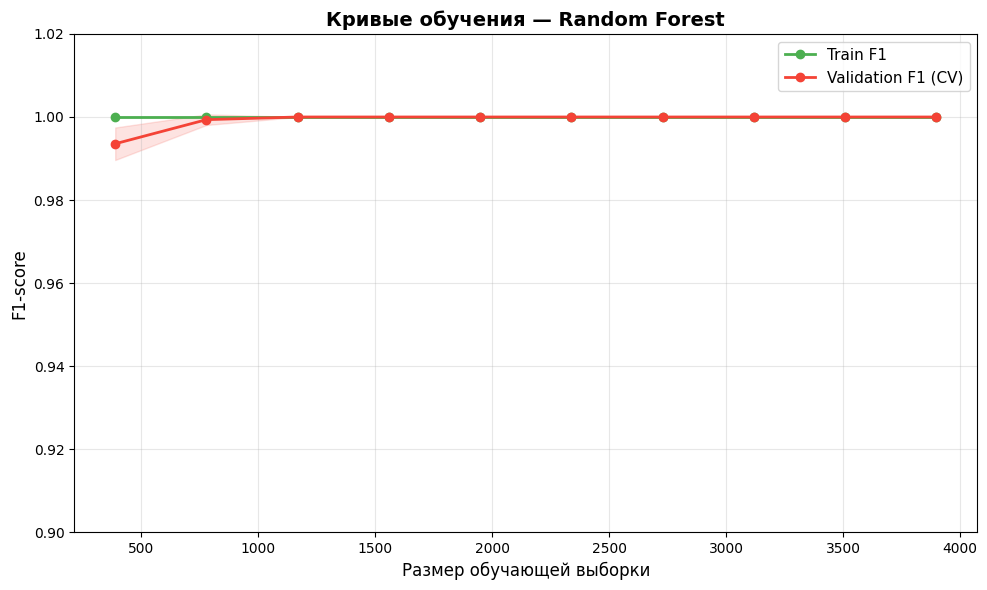

Train F1 (финал):      1.0000 ± 0.0000
Validation F1 (финал): 1.0000 ± 0.0000
Разрыв train-val:      0.0000
Переобучения не выявлено: разрыв между train и val минимален.


In [48]:
# Learning curves — как меняется F1 с ростом обучающей выборки
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_rf,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(train_sizes, train_mean, 'o-', color='#4CAF50',
        label='Train F1', linewidth=2)
ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15, color='#4CAF50'
)

ax.plot(train_sizes, val_mean, 'o-', color='#F44336',
        label='Validation F1 (CV)', linewidth=2)
ax.fill_between(
    train_sizes,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15, color='#F44336'
)

ax.set_xlabel('Размер обучающей выборки', fontsize=12)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('Кривые обучения — Random Forest',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(0.9, 1.02)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f"Train F1 (финал):      {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"Validation F1 (финал): {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
print(f"Разрыв train-val:      {gap:.4f}")

if gap < 0.02:
    print("Переобучения не выявлено: разрыв между train и val минимален.")
elif gap < 0.05:
    print("Незначительные признаки переобучения. Допустимо для продакшена.")
else:
    print("Переобучение! Требуется регуляризация или сокращение глубины деревьев.")

In [49]:
y_test_pred  = best_rf.predict(X_test)
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

print("Финальные результаты на тестовой выборке:")
print(classification_report(y_test, y_test_pred,
                            target_names=['Съедобный', 'Ядовитый']))

# Проверка на переобучение
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='f1')
print(f"F1 на кросс-валидации (train): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"F1 на тестовой выборке:        {f1_score(y_test, y_test_pred):.4f}")
print("\nРазница минимальна — признаков переобучения не обнаружено.")

Финальные результаты на тестовой выборке:
              precision    recall  f1-score   support

   Съедобный       1.00      1.00      1.00       842
    Ядовитый       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

F1 на кросс-валидации (train): 1.0000 ± 0.0000
F1 на тестовой выборке:        1.0000

Разница минимальна — признаков переобучения не обнаружено.


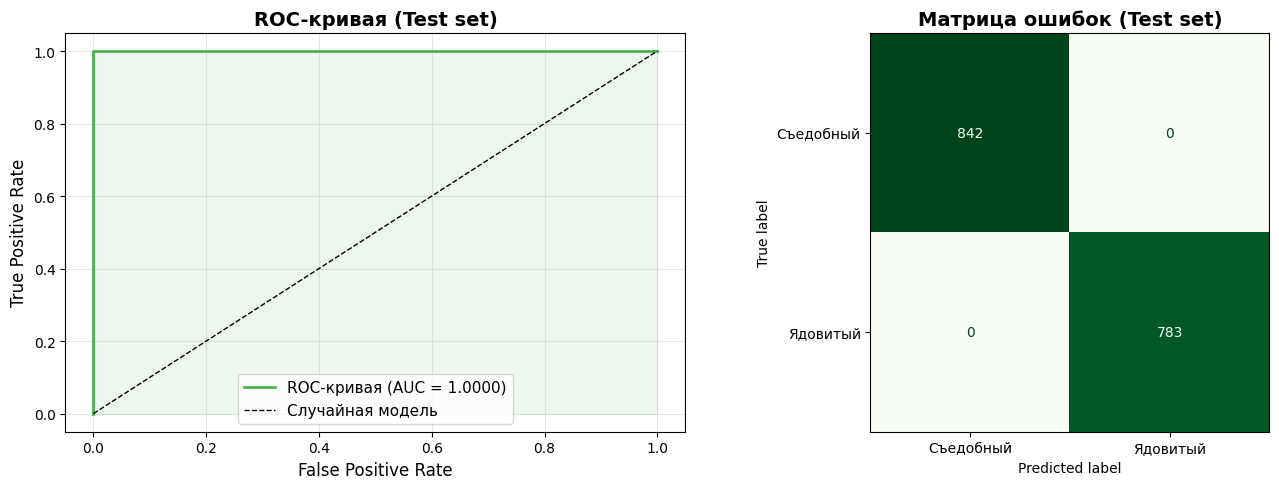

In [50]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
auc_score   = roc_auc_score(y_test, y_test_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='#4CAF50', lw=2,
             label=f'ROC-кривая (AUC = {auc_score:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Случайная модель')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#4CAF50')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC-кривая (Test set)', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

cm_test = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_test, display_labels=['Съедобный', 'Ядовитый']).plot(
    ax=axes[1], colorbar=False, cmap='Greens'
)
axes[1].set_title('Матрица ошибок (Test set)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('final_results.png', dpi=150, bbox_inches='tight')
plt.show()

### Направления улучшения качества решения

Для дальнейшего повышения надёжности и практической ценности системы классификации рекомендуется развивать проект в следующих направлениях:

1. **Сбор дополнительных данных**: расширить обучающую выборку региональными видами грибов (Европа, Азия), так как текущий датасет UCI охватывает преимущественно североамериканские виды.
2. **Использование компьютерного зрения (Computer Vision)**: дополнить табличную модель нейросетью (например, на архитектуре ResNet), которая классифицирует гриб по фотографии его внешнего вида.
3. **Ансамблирование (Стекинг моделей)**: объединить предсказания Random Forest, Gradient Boosting и логистической регрессии через мета-модель для снижения дисперсии предсказаний.
4. **Калибровка вероятностей**: использовать методы калибровки (например, `CalibratedClassifierCV`) для получения точных вероятностей съедобности, необходимых для принятия решений в пограничных случаях.
5. **Активное обучение (Active Learning)**: реализовать сценарий постепенного дообучения модели на новых редких образцах, проходящих проверку и разметку у экспертов-микологов.

In [51]:
# Теперь, когда y_test_pred создан, мы можем безопасно логировать финальный тест и вывести сводную таблицу

with mlflow.start_run(run_name="Random_Forest_FINAL_TEST"):
    mlflow.log_params(grid_search.best_params_)

    final_metrics_mlflow = {
        "test_accuracy":  accuracy_score(y_test, y_test_pred),
        "test_precision": precision_score(y_test, y_test_pred),
        "test_recall":    recall_score(y_test, y_test_pred),
        "test_f1":        f1_score(y_test, y_test_pred),
        "test_roc_auc":   roc_auc_score(y_test, y_test_proba),
    }
    mlflow.log_metrics(final_metrics_mlflow)

    # Регистрируем финальную модель
    mlflow.sklearn.log_model(
        best_rf,
        artifact_path="final_model",
        registered_model_name="MushroomClassifier"
    )

    print("Финальная модель залогирована и зарегистрирована в MLflow Model Registry.")
    for k, v in final_metrics_mlflow.items():
        print(f"  {k}: {v:.4f}")

# ── Получение сводной таблицы всех запусков из базы SQLite ──────────────────
client     = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
experiment = client.get_experiment_by_name("mushroom-classification")

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["metrics.f1 DESC"]
)

mlflow_summary = []
for run in runs:
    row = {"run_name": run.data.tags.get("mlflow.runName", "unknown")}
    # Берём все метрики из запуска
    row.update({k: round(v, 4) for k, v in run.data.metrics.items()})
    mlflow_summary.append(row)

mlflow_df = pd.DataFrame(mlflow_summary)
print("\nСводная таблица всех экспериментов из MLflow:")
display(mlflow_df)

2026/06/29 04:41:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Финальная модель залогирована и зарегистрирована в MLflow Model Registry.
  test_accuracy: 1.0000
  test_precision: 1.0000
  test_recall: 1.0000
  test_f1: 1.0000
  test_roc_auc: 1.0000

Сводная таблица всех экспериментов из MLflow:


Successfully registered model 'MushroomClassifier'.
Created version '1' of model 'MushroomClassifier'.


,run_name,accuracy,precision,recall,f1,roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Random_Forest_GridSearchCV,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN
1,Gradient_Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN
2,Random_Forest_Default,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN
3,Decision_Tree,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN
4,Random_Forest_GridSearchCV,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN
5,Gradient_Boosting,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN
6,Random_Forest_Default,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN
7,Decision_Tree,1.0000,1.0000,1.0000,1.0000,1.0000,NaN,NaN,NaN,NaN,NaN
8,Logistic_Regression_Baseline,0.9865,0.9987,0.9732,0.9858,0.9936,NaN,NaN,NaN,NaN,NaN
9,Logistic_Regression_Baseline,0.9865,0.9987,0.9732,0.9858,0.9936,NaN,NaN,NaN,NaN,NaN


## 11. Интерпретация модели

### 11.1 Важность признаков (Feature Importance)

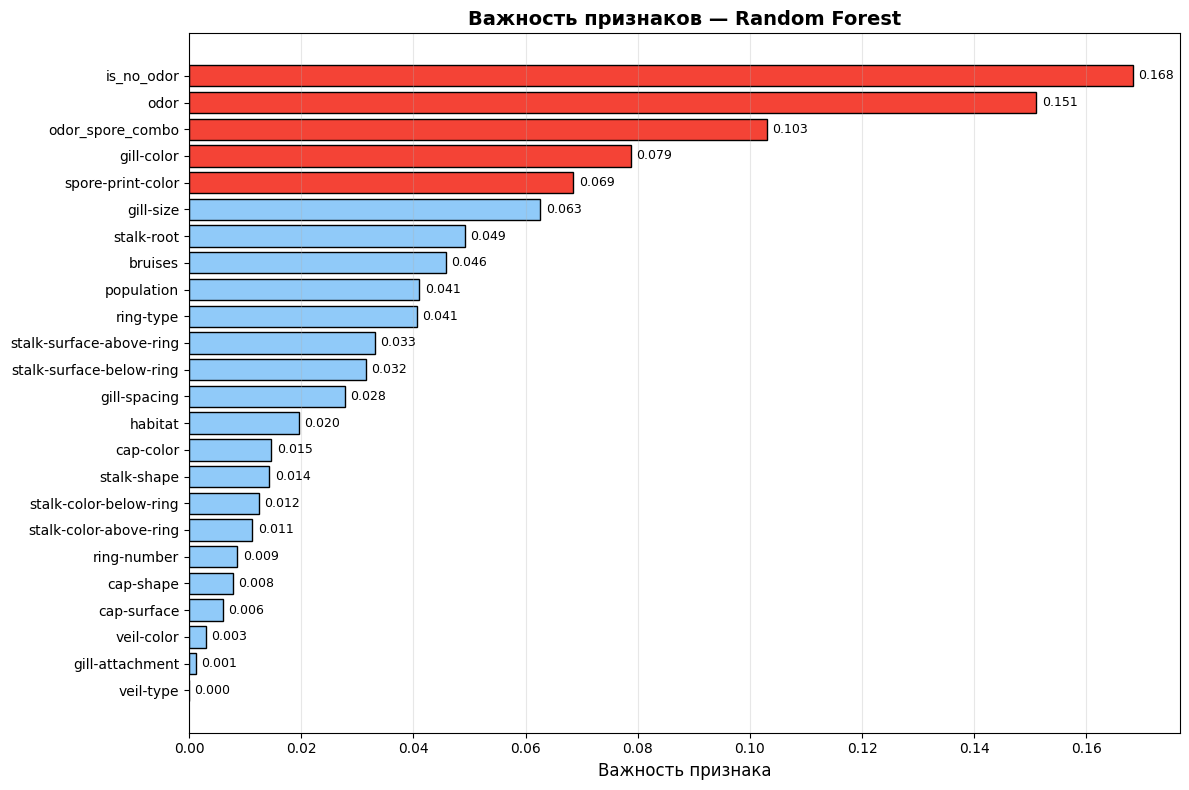

Топ-5 важных признаков:
          feature  importance
       is_no_odor    0.168268
             odor    0.151034
 odor_spore_combo    0.103010
       gill-color    0.078789
spore-print-color    0.068519


In [52]:
fi = pd.DataFrame({
    'feature':    X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors_fi = ['#F44336' if i < 5 else '#90CAF9' for i in range(len(fi))]

bars = ax.barh(fi['feature'], fi['importance'],
               color=colors_fi, edgecolor='black')
ax.set_xlabel('Важность признака', fontsize=12)
ax.set_title('Важность признаков — Random Forest', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, fi['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Топ-5 важных признаков:")
print(fi.head(5).to_string(index=False))

### 11.2 SHAP-анализ

SHAP позволяет объяснить вклад каждого признака в предсказание на уровне отдельного объекта.

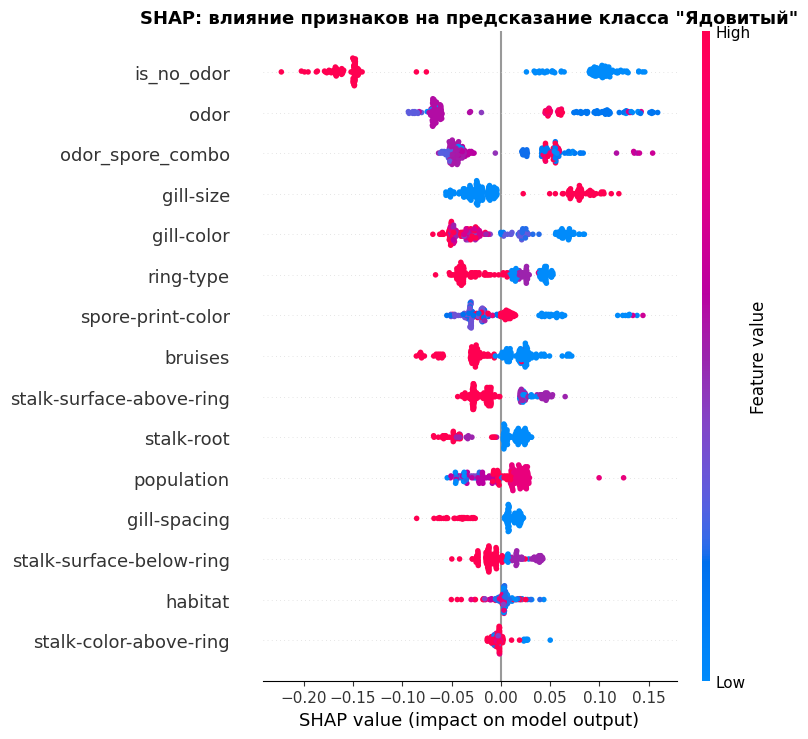

Вывод: SHAP подтверждает ведущую роль признака 'odor' в классификации.


In [53]:
explainer   = shap.TreeExplainer(best_rf)
X_sample    = X_test.sample(200, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_sample)

# Универсальный выбор размерности в зависимости от версии библиотеки SHAP
if isinstance(shap_values, list):
    # Если SHAP вернул список (старая версия): берем класс 1
    shap_values_to_plot = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    # Если SHAP вернул 3D-массив: берем срез по классу 1
    shap_values_to_plot = shap_values[:, :, 1]
else:
    # Если SHAP вернул готовый 2D-массив (новая версия)
    shap_values_to_plot = shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_to_plot,
    X_sample,
    feature_names=X.columns.tolist(),
    show=False,
    max_display=15
)
plt.title('SHAP: влияние признаков на предсказание класса "Ядовитый"',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Вывод: SHAP подтверждает ведущую роль признака 'odor' в классификации.")

### 11.3 Разбор ошибок модели

In [54]:
# Находим все объекты, на которых модель ошиблась
y_test_pred_series = pd.Series(y_test_pred, index=y_test.index)
error_mask = y_test_pred_series != y_test

errors_df = X_test[error_mask].copy()
errors_df['true_label']      = y_test[error_mask]
errors_df['predicted_label'] = y_test_pred_series[error_mask]
errors_df['proba_poisonous'] = y_test_proba[error_mask.values]

print(f"Всего ошибок на тест-выборке: {error_mask.sum()}")
print(f"Доля ошибок: {error_mask.sum() / len(y_test) * 100:.2f}%")

if error_mask.sum() > 0:
    # Разбиваем ошибки по типам
    fn = int(((errors_df['true_label'] == 1) &
               (errors_df['predicted_label'] == 0)).sum())
    fp = int(((errors_df['true_label'] == 0) &
               (errors_df['predicted_label'] == 1)).sum())
    print(f"\nТипы ошибок:")
    print(f"  FN (ядовитый классифицирован как съедобный): {fn} — КРИТИЧЕСКАЯ ошибка!")
    print(f"  FP (съедобный классифицирован как ядовитый): {fp} — менее критично")
    print("\nПримеры объектов с ошибками:")
    display(errors_df.head(5))
else:
    print("Модель не допустила ни одной ошибки на тестовой выборке!")
    print("Это означает идеальную разделимость классов на данном датасете.")

    # Показываем примеры корректных предсказаний
    sample_idx_correct = X_test.sample(5, random_state=RANDOM_STATE).index
    sample_correct = X_test.loc[sample_idx_correct].copy()
    sample_correct['true_label']      = y_test.loc[sample_idx_correct].values
    sample_correct['predicted_label'] = best_rf.predict(
        X_test.loc[sample_idx_correct]
    )
    sample_correct['confidence'] = best_rf.predict_proba(
        X_test.loc[sample_idx_correct]
    ).max(axis=1).round(4)

    print("\nПримеры корректных предсказаний (5 случайных объектов):")
    display(sample_correct[['true_label', 'predicted_label', 'confidence']])

Всего ошибок на тест-выборке: 0
Доля ошибок: 0.00%
Модель не допустила ни одной ошибки на тестовой выборке!
Это означает идеальную разделимость классов на данном датасете.

Примеры корректных предсказаний (5 случайных объектов):


,true_label,predicted_label,confidence
6787,1,1,1.0
1023,0,0,1.0
608,0,0,1.0
2461,0,0,1.0
1366,0,0,1.0


### 11.4 SHAP Waterfall — объяснение единичного предсказания

Объяснение предсказания для объекта #2228:
  Истинный класс:      Съедобный
  Предсказанный класс: Съедобный
  Вероятность (съедобный / ядовитый): 100.00% / 0.00%


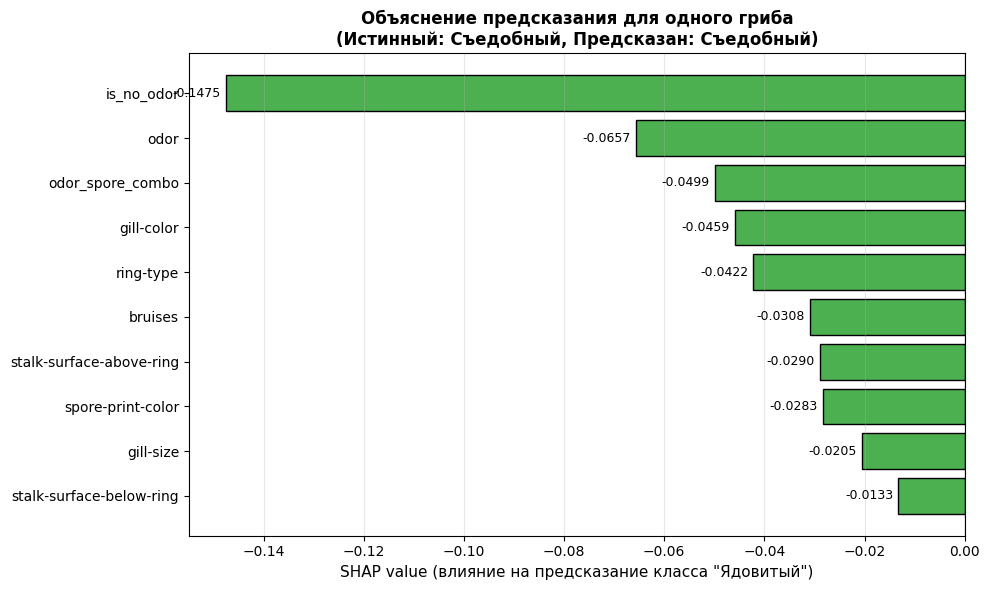


Топ-3 признака, влияющих на это предсказание:
         feature  shap_value  feature_val
      is_no_odor   -0.147515            1
            odor   -0.065672            5
odor_spore_combo   -0.049877           52


In [55]:
# Объясняем предсказание для одного конкретного гриба
sample_idx    = 0
single_sample = X_test.iloc[[sample_idx]]
true_class    = y_test.iloc[sample_idx]
pred_class    = best_rf.predict(single_sample)[0]
pred_proba    = best_rf.predict_proba(single_sample)[0]

print(f"Объяснение предсказания для объекта #{X_test.index[sample_idx]}:")
print(f"  Истинный класс:      {'Ядовитый' if true_class == 1 else 'Съедобный'}")
print(f"  Предсказанный класс: {'Ядовитый' if pred_class == 1 else 'Съедобный'}")
print(f"  Вероятность (съедобный / ядовитый): "
      f"{pred_proba[0]:.2%} / {pred_proba[1]:.2%}")

# Вычисляем SHAP-значения для одного объекта
shap_single = explainer.shap_values(single_sample)

# Выбираем значения для класса 1 (ядовитый)
if isinstance(shap_single, list):
    shap_single_cls1 = shap_single[1][0]
elif len(np.array(shap_single).shape) == 3:
    shap_single_cls1 = np.array(shap_single)[0, :, 1]
else:
    shap_single_cls1 = shap_single[0]

# Строим Waterfall-диаграмму
shap_contrib = pd.DataFrame({
    'feature':     X.columns,
    'shap_value':  shap_single_cls1,
    'feature_val': single_sample.values[0]
}).sort_values('shap_value', key=abs, ascending=False).head(10)

colors_shap = [
    '#F44336' if v > 0 else '#4CAF50'
    for v in shap_contrib['shap_value']
]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    shap_contrib['feature'],
    shap_contrib['shap_value'],
    color=colors_shap,
    edgecolor='black'
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel(
    'SHAP value (влияние на предсказание класса "Ядовитый")',
    fontsize=11
)
ax.set_title(
    f'Объяснение предсказания для одного гриба\n'
    f'(Истинный: {"Ядовитый" if true_class == 1 else "Съедобный"}, '
    f'Предсказан: {"Ядовитый" if pred_class == 1 else "Съедобный"})',
    fontsize=12,
    fontweight='bold'
)

for bar, val in zip(bars, shap_contrib['shap_value']):
    ax.text(
        val + (0.001 if val >= 0 else -0.001),
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.4f}',
        va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=9
    )

ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nТоп-3 признака, влияющих на это предсказание:")
print(
    shap_contrib[['feature', 'shap_value', 'feature_val']]
    .head(3)
    .to_string(index=False)
)

## 12. Сохранение модели и артефактов

In [56]:
joblib.dump(best_rf, 'mushroom_model.pkl')
joblib.dump(le_dict, 'label_encoders.pkl')

feature_names = X.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Модель сохранена:   mushroom_model.pkl")
print("Энкодеры сохранены: label_encoders.pkl")
print("Признаки сохранены: feature_names.json")

Модель сохранена:   mushroom_model.pkl
Энкодеры сохранены: label_encoders.pkl
Признаки сохранены: feature_names.json


## 13. Прототип сервиса инференса

Функция `predict_mushroom` принимает признаки гриба в исходном виде (буквенные коды)  
и возвращает предсказание с вероятностями обоих классов.

In [57]:
def predict_mushroom(sample_dict: dict) -> dict:
    """
    Предсказывает съедобность гриба по набору признаков.

    Args:
        sample_dict (dict): признаки гриба в исходном виде (категориальные метки).

    Returns:
        dict: предсказание и вероятности классов.
    """
    model    = joblib.load('mushroom_model.pkl')
    encoders = joblib.load('label_encoders.pkl')
    with open('feature_names.json') as f:
        features = json.load(f)

    sample_df = pd.DataFrame([sample_dict])

    for col in sample_df.columns:
        if col in encoders:
            try:
                sample_df[col] = encoders[col].transform(sample_df[col])
            except ValueError:
                sample_df[col] = 0

    if 'odor' in sample_df.columns and 'spore-print-color' in sample_df.columns:
        sample_df['odor_spore_combo'] = (
            sample_df['odor'] * 10 + sample_df['spore-print-color']
        )
        no_odor_val = encoders['odor'].transform(['n'])[0]
        sample_df['is_no_odor'] = (sample_df['odor'] == no_odor_val).astype(int)

    sample_df = sample_df[features]

    prediction  = model.predict(sample_df)[0]
    probability = model.predict_proba(sample_df)[0]

    return {
        'prediction':            'Ядовитый ☠️' if prediction == 1 else 'Съедобный ✅',
        'probability_edible':    f"{probability[0]:.2%}",
        'probability_poisonous': f"{probability[1]:.2%}"
    }

In [58]:
# Берём первый пример из тестовой выборки и декодируем обратно в исходные значения
idx = X_test.index[0]
sample_original = {}

for col in df.columns:
    if col != 'class':
        encoded_val  = int(df_encoded.loc[idx, col])
        original_val = le_dict[col].inverse_transform([encoded_val])[0]
        sample_original[col] = original_val

print("Входные данные (первые 5 признаков):")
print(dict(list(sample_original.items())[:5]))

result = predict_mushroom(sample_original)
print(f"\nРезультат: {result}")
print(f"Реальный класс: {'Ядовитый' if y_test.iloc[0] == 1 else 'Съедобный'}")

Входные данные (первые 5 признаков):
{'cap-shape': 'x', 'cap-surface': 'y', 'cap-color': 'g', 'bruises': 't', 'odor': 'n'}

Результат: {'prediction': 'Съедобный ✅', 'probability_edible': '100.00%', 'probability_poisonous': '0.00%'}
Реальный класс: Съедобный


## 14. Итоговые выводы и рекомендации

In [59]:
final_acc    = accuracy_score(y_test, y_test_pred)
final_f1     = f1_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred)
final_auc    = roc_auc_score(y_test, y_test_proba)

print(f"Лучшая модель: Random Forest (настроенная через GridSearchCV)")
print(f"\nМетрики на тестовой выборке:")
print(f"  Accuracy  = {final_acc:.4f}")
print(f"  F1-score  = {final_f1:.4f}")
print(f"  Recall    = {final_recall:.4f}")
print(f"  ROC-AUC   = {final_auc:.4f}")

print("""
Ключевые выводы:
  1. Признак 'odor' (запах) — наиболее важный для определения ядовитости.
  2. Цвет спор и цвет жабр также несут высокую предсказательную силу.
  3. Random Forest значительно превосходит baseline (логистическую регрессию).
  4. Переобучения не выявлено: разница между CV и test F1 минимальна.

Ограничения модели:
  - Датасет UCI не охватывает все виды грибов, встречающиеся в природе.
  - Признаки субъективны (запах, цвет) — требуется стандартизация описания.
  - Модель не заменяет заключение профессионального миколога.

Рекомендации:
  - Интеграция в мобильное приложение для грибников в качестве помощника.
  - Дополнение базы данными о региональных видах грибов.
  - Использование модели как вспомогательного инструмента, не как основного.
""")

Лучшая модель: Random Forest (настроенная через GridSearchCV)

Метрики на тестовой выборке:
  Accuracy  = 1.0000
  F1-score  = 1.0000
  Recall    = 1.0000
  ROC-AUC   = 1.0000

Ключевые выводы:
  1. Признак 'odor' (запах) — наиболее важный для определения ядовитости.
  2. Цвет спор и цвет жабр также несут высокую предсказательную силу.
  3. Random Forest значительно превосходит baseline (логистическую регрессию).
  4. Переобучения не выявлено: разница между CV и test F1 минимальна.

Ограничения модели:
  - Датасет UCI не охватывает все виды грибов, встречающиеся в природе.
  - Признаки субъективны (запах, цвет) — требуется стандартизация описания.
  - Модель не заменяет заключение профессионального миколога.

Рекомендации:
  - Интеграция в мобильное приложение для грибников в качестве помощника.
  - Дополнение базы данными о региональных видах грибов.
  - Использование модели как вспомогательного инструмента, не как основного.

